In [50]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from IPython.display import Audio
from scipy.interpolate import interp1d

In [51]:
@njit
def fnl(p, alpha, P0, pf, smoothness=30):
    smooth_step = 0.5 * (1.0 + np.tanh(smoothness * (p - pf)))

    return alpha * (P0 - p) * (p - pf)  * smooth_step

In [52]:
@njit
def simulate_explicit_euler(
    t,
    tau,
    sigma,
    beta,
    Z0S,
    alpha,
    P0,
    pf,    
    p_history,
    u_history,
):
    """
    Explicit-Euler discretization of

        du/dt = (fnl(p) - u) / tau

        dp/dt + sigma p(t) + beta p(t-T)
          = (Z0/S) [ du/dt + sigma u(t) - beta u(t-T) ]

    on a uniform grid t = [0, dt, 2dt, ..., tmax].

    Parameters
    ----------
    t : array, shape (N,)
        Uniform time grid on [0, tmax].
    tau, sigma, beta, Z0, S : float
        Model parameters.
    fnl : callable
        Nonlinearity, called as fnl(p_n) -> scalar.
    p_history, u_history : array, shape (M+1,)
        History values over [-T, 0], sampled on the same dt grid.
        Must be ordered as:
            [ value at -T, ..., value at -dt, value at 0 ]
        so len(...) = M+1 and T = M*dt.

    Returns
    -------
    p, u : arrays, shape (N,)
        Solution on the grid t.
    """
    dt = t[1] - t[0]
    N = len(t)
    
    M = len(p_history) - 1  # so T = M*dt

    p = np.zeros(N)
    u = np.zeros(N)

    # initialize at t=0 from history
    p[0] = p_history[-1]
    u[0] = u_history[-1]

    for n in range(N - 1):
        # delayed samples at time t_n - T = t_{n-M}
        delayed_idx = n - M
        if delayed_idx >= 0:
            p_delay = p[delayed_idx]
            u_delay = u[delayed_idx]
        else:
            # map:
            # delayed_idx = -M,...,0 corresponds to history[0],...,M
            p_delay = p_history[delayed_idx + M]
            u_delay = u_history[delayed_idx + M]

        fnl_p = fnl(p[n], alpha, P0, pf)

        # recurrence pair
        u[n + 1] = u[n] + (dt / tau) * (fnl_p - u[n])

        p[n + 1] = (
            p[n]
            + dt * (Z0S) * ((fnl_p - u[n]) / tau + sigma * u[n] - beta * u_delay)
            - dt * (sigma * p[n] + beta * p_delay)
        )

    return p, u

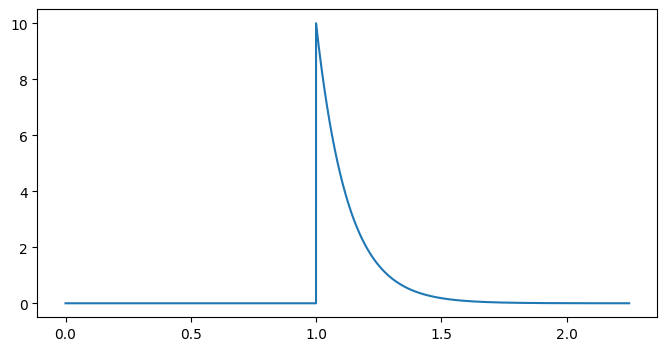

/home/miles/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


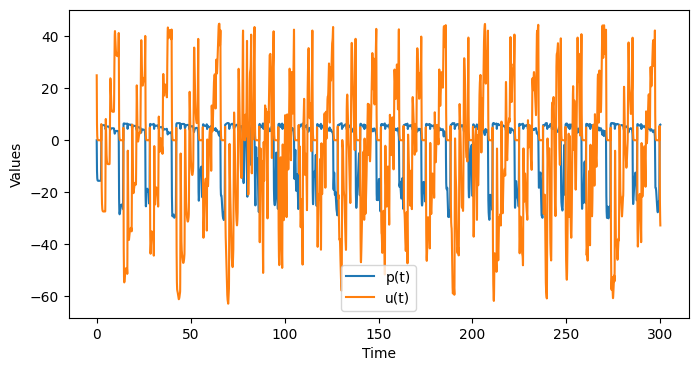

In [53]:
# time grid
dt = 0.5e-4
tmax = 300
t = np.arange(0.0, tmax + dt, dt)

# delay T = M*dt
T = 1
M = int(round(T / dt))

# parameters
tau = 1e-1
sigma = 8.0
beta = 10.0
Z0S = 0.5

P0 = 5
pf = -1
alpha = 5

# constant history on [-T, 0]
p0 = 0.0
u0 = fnl(p0, alpha, P0, pf)

hsize = int(round( (T+10/sigma) / dt))
p_history = np.full(hsize, p0, dtype=float)
u_history = np.full(hsize, u0, dtype=float)

p, u = simulate_explicit_euler(
    t=t,
    tau=tau,
    sigma=sigma,
    beta=beta,
    Z0S=Z0S,
    alpha=alpha,
    P0=P0,
    pf=pf,
    p_history=p_history,
    u_history=u_history,
)

plt.figure(figsize=(8, 4))
# plot exponential reflecting boundary condition
tr = np.arange(0.0, T+10/sigma, dt)
r = np.exp(-sigma*(tr-T))*beta*(tr>=T)
plt.plot(tr, r, label="r(t)")

plt.figure(figsize=(8, 4))
plt.plot(t, p, label="p(t)")
plt.plot(t, u, label="u(t)")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.show()

fr = 8000
t_interp = np.arange(0.0, tmax / 1000, 1 / fr)
interp_func = interp1d(t / 1000, p, kind='cubic')
p_interp = interp_func(t_interp)
Audio(data=np.array(p_interp, dtype=np.float32), rate=fr)

In [54]:
#RK4 version

@njit
def simulate_rk4(
    t,
    tau,
    sigma,
    beta,
    Z0S,
    alpha,
    P0,
    pf,
    p_history,
    u_history,
):
    """
    RK4 discretization of the DDE system:

        du/dt = (fnl(p) - u) / tau

        dp/dt = Z0S * [(fnl(p) - u)/tau + sigma*u(t) - beta*u(t-T)]
                - sigma*p(t) - beta*p(t-T)

    Delayed values at the RK4 half-step are obtained by linear interpolation
    between the two surrounding grid points.

    Parameters
    ----------
    t : array, shape (N,)
        Uniform time grid on [0, tmax].
    tau, sigma, beta, Z0S : float
        Model parameters.
    alpha, P0, pf : float
        Parameters for the nonlinearity fnl.
    p_history, u_history : array, shape (M+1,)
        History on [-T, 0] with T = M*dt. Ordered as
        [value at -T, ..., value at -dt, value at 0].

    Returns
    -------
    p, u : arrays, shape (N,)
        Solution on the grid t.
    """
    dt = t[1] - t[0]
    N = len(t)
    M = len(p_history) - 1  # T = M*dt

    p = np.zeros(N)
    u = np.zeros(N)

    p[0] = p_history[-1]
    u[0] = u_history[-1]

    for n in range(N - 1):
        i0 = n - M      # grid index for delay at t_n - T
        i1 = n - M + 1  # grid index for delay at t_{n+1} - T

        # Delayed p and u at t_n - T
        pd0 = p[i0] if i0 >= 0 else p_history[i0 + M]
        ud0 = u[i0] if i0 >= 0 else u_history[i0 + M]

        # Delayed p and u at t_{n+1} - T
        pd1 = p[i1] if i1 >= 0 else p_history[i1 + M]
        ud1 = u[i1] if i1 >= 0 else u_history[i1 + M]

        # Linear interpolation for mid-step delay at t_n + dt/2 - T
        pd_half = 0.5 * (pd0 + pd1)
        ud_half = 0.5 * (ud0 + ud1)

        # k1 — evaluated at (t_n, p_n, u_n) with delay at t_n - T
        fnl1 = fnl(p[n], alpha, P0, pf)
        du1  = (fnl1 - u[n]) / tau
        dp1  = Z0S * (du1 + sigma * u[n] - beta * ud0) - sigma * p[n] - beta * pd0

        # k2 — midpoint estimate with delay at t_n + dt/2 - T
        p2   = p[n] + 0.5 * dt * dp1
        u2   = u[n] + 0.5 * dt * du1
        fnl2 = fnl(p2, alpha, P0, pf)
        du2  = (fnl2 - u2) / tau
        dp2  = Z0S * (du2 + sigma * u2 - beta * ud_half) - sigma * p2 - beta * pd_half

        # k3 — corrected midpoint estimate with delay at t_n + dt/2 - T
        p3   = p[n] + 0.5 * dt * dp2
        u3   = u[n] + 0.5 * dt * du2
        fnl3 = fnl(p3, alpha, P0, pf)
        du3  = (fnl3 - u3) / tau
        dp3  = Z0S * (du3 + sigma * u3 - beta * ud_half) - sigma * p3 - beta * pd_half

        # k4 — full-step estimate with delay at t_{n+1} - T
        p4   = p[n] + dt * dp3
        u4   = u[n] + dt * du3
        fnl4 = fnl(p4, alpha, P0, pf)
        du4  = (fnl4 - u4) / tau
        dp4  = Z0S * (du4 + sigma * u4 - beta * ud1) - sigma * p4 - beta * pd1

        # Weighted combination
        p[n + 1] = p[n] + (dt / 6.0) * (dp1 + 2.0*dp2 + 2.0*dp3 + dp4)
        u[n + 1] = u[n] + (dt / 6.0) * (du1 + 2.0*du2 + 2.0*du3 + du4)

    return p, u


/home/miles/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


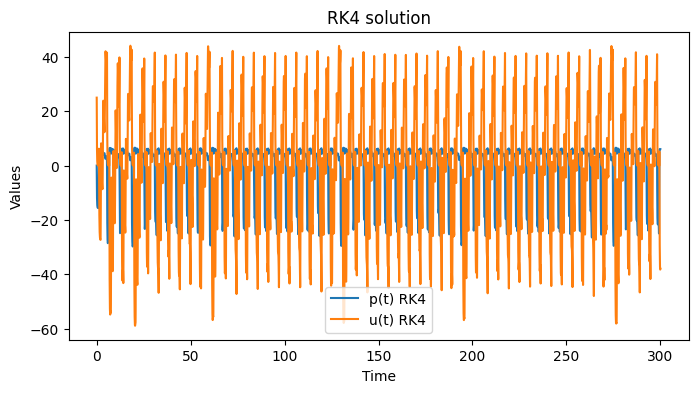

In [55]:
# # time grid
# dt = 1e-4
# tmax = 300
# t = np.arange(0.0, tmax + dt, dt)

# # delay T = M*dt
# T = 1
# M = int(round(T / dt))

# # parameters
# tau = 1e-1
# sigma = 8.0
# beta = -10.0
# Z0S = 1.0

# P0 = 1
# pf = -1
# alpha = 5

# constant history on [-T, 0]
p0 = 0.0
u0 = fnl(p0, alpha, P0, pf)
p_history = np.full(M + 1, p0, dtype=float)
u_history = np.full(M + 1, u0, dtype=float)

p_rk4, u_rk4 = simulate_rk4(
    t=t,
    tau=tau,
    sigma=sigma,
    beta=beta,
    Z0S=Z0S,
    alpha=alpha,
    P0=P0,
    pf=pf,
    p_history=p_history,
    u_history=u_history,
)

plt.figure(figsize=(8, 4))
plt.plot(t, p_rk4, label="p(t) RK4")
plt.plot(t, u_rk4, label="u(t) RK4")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.title("RK4 solution")
plt.show()

t_interp = np.arange(0.0, tmax / 1000, 1 / fr)
interp_func = interp1d(t / 1000, u_rk4, kind='cubic')
u_rk4_interp = interp_func(t_interp)
Audio(data=np.array(u_rk4_interp, dtype=np.float32), rate=fr)
